<a href="https://colab.research.google.com/github/jenny4890/deepLearning/blob/main/MaskRCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt # 코랩 출력을 위해 추가
from torchvision.io.image import decode_image
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

img = decode_image("test0526.jpg")

# Step 1: Initialize model with the best available weights
weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = maskrcnn_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)
prediction = model(batch)[0]
print(prediction.keys())



Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:15<00:00, 11.8MB/s]


dict_keys(['boxes', 'labels', 'scores', 'masks'])


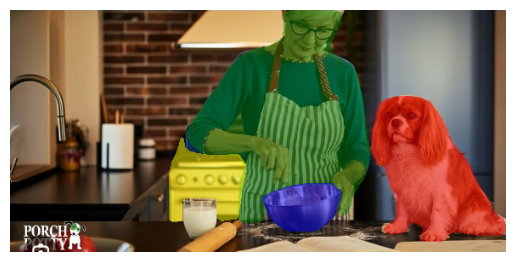

In [5]:

from torchvision.utils import draw_segmentation_masks
import matplotlib.pyplot as plt

colors = ["red", "green", "blue", "yellow", "purple", "orange"]

result_img = img.clone()
for idx in range(prediction['scores'].shape[0]):
    score = prediction['scores'][idx]
    if score < 0.9:
        break
    color = colors[idx % len(colors)]
    mask = 0.5 < prediction['masks'][idx]
    result_img = draw_segmentation_masks(result_img, mask, alpha=0.5, colors=color)

plt.imshow(to_pil_image(result_img))
plt.axis('off')
plt.show()